In [49]:
import numpy as np
import pandas as pd
from casadi import *
from scipy.spatial import KDTree
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from Functions.Utils import *
from Functions.Graphs import *

def RaceTrackOffset(x, y, d=2.0):
    """
    Gera uma nova pista paralela onde cada ponto (x2, y2) dista exatamente
    'd' metros do ponto correspondente (x, y) original.
    
    d > 0: Desloca para um lado (ex: direita/fora)
    d < 0: Desloca para o lado oposto (ex: esquerda/dentro)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    
    # Vetores para armazenar as direções normais
    nx = np.zeros(n)
    ny = np.zeros(n)
    
    # Calcula os vetores normais para cada ponto da pista
    for i in range(n):
        # Definição dos pontos vizinhos para cálculo da tangente local
        if i == 0:
            # Primeiro ponto: usa o próximo
            tx = x[1] - x[0]
            ty = y[1] - y[0]
        elif i == n - 1:
            # Último ponto: usa o anterior
            tx = x[n-1] - x[n-2]
            ty = y[n-1] - y[n-2]
        else:
            # Pontos intermediários: diferença centralizada para maior precisão
            tx = x[i+1] - x[i-1]
            ty = y[i+1] - y[i-1]
            
        # Magnitude (comprimento) do vetor tangente
        norma = np.sqrt(tx**2 + ty**2)
        if norma == 0:
            norma = 1e-6
            
        # Vetor tangente unitário
        tx /= norma
        ty /= norma
        
        # Rotaciona o vetor tangente em 90 graus para obter a normal unitária (nx, ny)
        nx[i] = -ty
        ny[i] = tx
        
    # Aplica o deslocamento exato de 'd' metros
    x_history2 = x + d * nx
    y_history2 = y + d * ny
    
    return x_history2, y_history2

1. LOAD RACETRACK DATA & SPATIAL PARAMETRIZATION

In [50]:
path = r'DyntheticDataset\RaceTrack4.csv'
df = pd.read_csv(path)
x_mid = df['x_coords'].values[:]
y_mid = df['y_coords'].values[:]

dt = 0.1  # Control & Simulation evaluation step size (100ms)

# Ensure the track loops closed cleanly
if not np.allclose([x_mid[0], y_mid[0]], [x_mid[-1], y_mid[-1]]):
    x_mid = np.append(x_mid, x_mid[0])
    y_mid = np.append(y_mid, y_mid[0])

track_points = np.vstack((x_mid, y_mid)).T
track_tree = KDTree(track_points)

# Calculate cumulative distance (arc length 's') along track coordinates
dx = np.diff(x_mid)
dy = np.diff(y_mid)
segment_lengths = np.sqrt(dx**2 + dy**2)
s_coor = np.insert(np.cumsum(segment_lengths), 0, 0.0)
track_length = s_coor[-1]

# Linear interpolators to find exact continuous (x, y) coordinates for any distance s
get_x_at_s = interp1d(s_coor, x_mid, kind='linear', bounds_error=False, fill_value="extrapolate")
get_y_at_s = interp1d(s_coor, y_mid, kind='linear', bounds_error=False, fill_value="extrapolate")

2. CASADI OPTI PROBLEM CONFIGURATION (Defined ONCE outside loop)


In [51]:
n_horizon = 32
l = 2.5 # Wheelbase

opti = Opti()

# Decision variables over the prediction horizon
X = opti.variable(4, n_horizon + 1) # States: [x_pos, y_pos, v, psi]
U = opti.variable(2, n_horizon)     # Controls: [a, delta]

# Parameters
X0 = opti.parameter(4)
X_REF = opti.parameter(n_horizon)
Y_REF = opti.parameter(n_horizon)
V_REF = opti.parameter(n_horizon)
V_MAX_CEILING = opti.parameter(n_horizon)

obj = 0
opti.subject_to(X[:, 0] == X0)

# Build the execution graph symbolic tree once
for k in range(n_horizon):
    x_k   = X[0, k]
    y_k   = X[1, k]
    v_k   = X[2, k]
    psi_k = X[3, k]
    
    a_k     = U[0, k]
    delta_k = U[1, k]

    beta = atan(0.5 * tan(delta_k))
    
    next_x   = x_k + dt * (v_k * cos(psi_k + beta))
    next_y   = y_k + dt * (v_k * sin(psi_k + beta))
    next_v   = v_k + dt * a_k
    next_psi = psi_k + dt * ((v_k / l) * sin(beta))

    opti.subject_to(X[0, k+1] == next_x)
    opti.subject_to(X[1, k+1] == next_y)
    opti.subject_to(X[2, k+1] == next_v)
    opti.subject_to(X[3, k+1] == next_psi)

    # Stage cost
    obj += (x_k - X_REF[k])**2 + (y_k - Y_REF[k])**2 + 5.0 * (v_k - V_REF[k])**2
    obj += 0.125 * a_k**2 + 0.25 * delta_k**2

# CRITICAL FIX: Replaced [-1] negative indexing with explicit [n_horizon - 1]
obj += (X[0, n_horizon] - X_REF[n_horizon - 1])**2 + \
       (X[1, n_horizon] - Y_REF[n_horizon - 1])**2 + \
       5.0 * (X[2, n_horizon] - V_REF[n_horizon - 1])**2

opti.minimize(obj)

# Bounds
opti.subject_to(opti.bounded(-10.0, U[0, :], 5.0))                 
opti.subject_to(opti.bounded(-np.deg2rad(30), U[1, :], np.deg2rad(30))) 
opti.subject_to(opti.bounded(0.0, X[2, :], 20.0))                  

# Setup solver configuration options once
opts = {"ipopt.print_level": 0, "print_time": 0, "ipopt.warm_start_init_point": "yes"}
opti.solver('ipopt', opts)

3. CLOSED-LOOP SIMULATION LOOP


In [52]:
s_total_traveled = 0.0
last_current_idx = 0

x0_start = np.array([x_mid[0], y_mid[0], 0.0, 0.0])
x_current = x0_start.copy()
current_time = 0.0

t_history = [current_time]
x_history = [x_current[0]]
y_history = [x_current[1]]
v_history = [x_current[2]]
v_ref_history = []
acc_history = [0]
delta_history = [0]
psi_history = [0]
is_turning_sharp = False
turning = []
sim_steps = 275

# Continuous trajectory memory for warm-starting
last_sol_X = np.tile(x_current.reshape(4, 1), (1, n_horizon + 1))
last_sol_U = np.zeros((2, n_horizon))

for step in range(sim_steps):
    if step % 50 == 0 :print('step:',step)
    _, current_idx = track_tree.query([x_current[0], x_current[1]])
    
    idx_diff = current_idx - last_current_idx
    if idx_diff < -len(x_mid)/2: 
        idx_diff += len(x_mid)
    elif idx_diff > len(x_mid)/2:
        idx_diff -= len(x_mid)
        
    if idx_diff > 0:
        s_total_traveled += np.sum(segment_lengths[last_current_idx:current_idx])
    last_current_idx = current_idx

    # Generate Time-Varying Horizon Reference Profiles
    s_projected = s_coor[current_idx]
    x_ref_horizon = np.zeros(n_horizon)
    y_ref_horizon = np.zeros(n_horizon)
    v_ref_horizon = np.zeros(n_horizon)
    #is_turning_sharp = (x_current[3] >= np.deg2rad(5)) or (x_current[3] <= -np.deg2rad(5))
    is_turning_sharp = (abs(x_current[3]) >= np.deg2rad(5))
    turning.append(is_turning_sharp)

    for k in range(n_horizon):
        s_projected += max(x_current[2], 1.5) * dt 
        s_wrapped = s_projected % track_length
        
        x_ref_horizon[k] = get_x_at_s(s_wrapped)
        y_ref_horizon[k] = get_y_at_s(s_wrapped)
        
        if s_total_traveled >= track_length * 1.8:
            v_ref_horizon[k] = 0.0
        elif is_turning_sharp:
            v_ref_horizon[k] = 10
        else:
            v_ref_horizon[k] = 20.0

    # Update parameters
    opti.set_value(X0, x_current)
    opti.set_value(X_REF, x_ref_horizon)
    opti.set_value(Y_REF, y_ref_horizon)
    opti.set_value(V_REF, v_ref_horizon)
    

    # Seed guesses
    opti.set_initial(X, last_sol_X)
    opti.set_initial(U, last_sol_U)

    try:
        sol = opti.solve()
        u_control = sol.value(U[:, 0])
        last_sol_X = sol.value(X)
        last_sol_U = sol.value(U)
    except Exception as e:
        # Fallback: Retrieve the last non-optimal/sub-optimal values instead of crashing instantly
        u_control = opti.debug.value(U[:, 0])
        last_sol_X = opti.debug.value(X)
        last_sol_U = opti.debug.value(U)

    # --- Plant Simulator (Process Step using Forward Euler) ---
    beta_sim = np.arctan(0.5 * np.tan(u_control[1]))
    x_next = x_current[0] + dt * (x_current[2] * np.cos(x_current[3] + beta_sim))
    y_next = x_current[1] + dt * (x_current[2] * np.sin(x_current[3] + beta_sim))
    v_next = x_current[2] + dt * u_control[0]
    psi_next = x_current[3] + dt * ((x_current[2] / l) * np.sin(beta_sim))
    
    x_current = np.array([x_next, y_next, v_next, psi_next])
    current_time += dt

    t_history.append(current_time)
    x_history.append(x_current[0])
    y_history.append(x_current[1])
    v_history.append(x_current[2])
    v_ref_history.append(v_ref_horizon[0])
    acc_history.append(u_control[0])
    psi_history.append(x_current[3])
    delta_history.append(u_control[1])

    if s_total_traveled >= track_length and x_current[2] < 0.05:
        print(f"Simulation completed! Lap finished and vehicle stopped on centerline at step {step}.")
        break

# Convert historical data into numpy arrays for rendering 

t_history = np.array(t_history)
x_history = np.array(x_history)
y_history = np.array(y_history)
v_history = np.array(v_history)
v_ref_history = np.array(v_ref_horizon)
acc_history = np.array(acc_history)
delta_history = np.array(delta_history)
delta_history = np.rad2deg(delta_history)

psi_history = np.array(psi_history)
psi_history = np.rad2deg(psi_history)

x_history2,y_history2 = RaceTrackOffset(x_history,y_history,3)

step: 0
step: 50
step: 100
step: 150
step: 200
step: 250


4. PLOT RESULTS

In [59]:
PlotMPCTracksPLY(x_history, y_history, x_history2, y_history2,
                  psi_history, v_history, x_mid=x_mid, y_mid=y_mid)


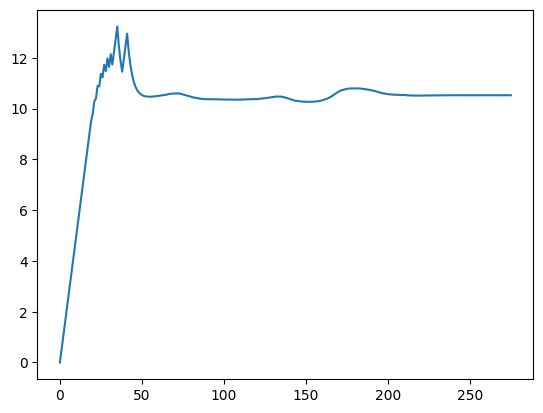

In [61]:
plt.plot(v_history)